## Imports

In [1]:
import random
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, mean_squared_error, confusion_matrix, ConfusionMatrixDisplay

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

## Utils

In [2]:
def get_data_root():
  '''
    Ritorna il percorso della cartella contenente i dati in base all'ambiente di esecuzione.
  '''
  try:
      import google.colab
      from google.colab import drive

      try:
          drive.mount("/content/drive", force_remount=True)
          return "/content/drive/MyDrive/ColabContent/Data_analytics"
      except Exception:
          print("Drive non montabile")
          return "/content"

  except ImportError:
      return "../../data"

print(get_data_root())

Mounted at /content/drive
/content/drive/MyDrive/ColabContent/Data_analytics


## Global variables

In [3]:
DATA_ROOT = get_data_root()
DATASET_PATH = f"{DATA_ROOT}/Dataset2526/train.csv"
TRAIN_SET_PATH = f"{DATA_ROOT}/train_processed.csv"
VAL_SET_PATH = f"{DATA_ROOT}/val_processed.csv"
TEST_SET_PATH = f"{DATA_ROOT}/test_processed.csv"
SEED = 42

Mounted at /content/drive


## Seed per riproducibilità

In [4]:
def fix_random(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

## Impostazione GPU

In [5]:
# look for GPU
if torch.backends.mps.is_available():
    print("MPS device is available.")
    device = torch.device("mps")
elif torch.cuda.is_available():
    print("CUDA device is available.")
    device = torch.device("cuda")
else:
    print("No GPU acceleration available.")
    device = torch.device("cpu")

CUDA device is available.


## Definizione data loader

In [6]:
class MyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values if hasattr(X, 'values') else X, dtype=torch.float32)
        self.y = torch.tensor(y.values if hasattr(y, 'values') else y, dtype=torch.long)

        self.num_features = self.X.shape[1]
        self.num_classes = len(torch.unique(self.y))

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

## Caricamento dati

In [7]:
train = pd.read_csv(TRAIN_SET_PATH)
val = pd.read_csv(VAL_SET_PATH)
test = pd.read_csv(TEST_SET_PATH)

X_train = train.drop(columns=['grade'])
y_train = train["grade"]

X_val = val.drop(columns=['grade'])
y_val = val["grade"]

X_test = test.drop(columns=['grade'])
y_test = test["grade"]

print(f"TRAIN:\nX: {X_train.shape}\ny: {y_train.shape}")
print(f"VAL:\nX: {X_val.shape}\ny: {y_val.shape}")
print(f"TEST:\nX: {X_test.shape}\ny: {y_test.shape}")

TRAIN:
X: (33747, 38)
y: (33747,)
VAL:
X: (14830, 38)
y: (14830,)
TEST:
X: (14831, 38)
y: (14831,)


# Modeling (Feed-Forward)

### Architettura feed-forward

In [8]:
class FeedForward(nn.Module):
    def __init__(self, input_size, num_classes, hidden_size, dropout_prob=0.2):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_prob),

            nn.Linear(hidden_size, hidden_size // 2),
            nn.BatchNorm1d(hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout_prob),

            nn.Linear(hidden_size // 2, hidden_size // 4),
            nn.BatchNorm1d(hidden_size // 4),
            nn.ReLU(),
            nn.Dropout(dropout_prob),

            nn.Linear(hidden_size // 4, num_classes)
        )

    def forward(self, x):
        return self.net(x)

### Funzione di train

In [9]:
def train_model(model, criterion, optimizer, epoch, scheduler,
                train_loader, val_loader, device, writer,
                log_name="ff_best_model", patience=10):

    best_valid_loss = float('inf')
    epochs_no_improve = 0
    early_stop = False

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for ep in range(epoch):
        if early_stop:
            print(f"Early stopping attivato all'epoca {ep}")
            break

        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        # Train loop
        for data, targets in train_loader:
            data, targets = data.to(device), targets.to(device)
            optimizer.zero_grad()
            y_pred = model(data)
            loss = criterion(y_pred, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * data.size(0)
            _, predicted = torch.max(y_pred, 1)
            correct_train += (predicted == targets).sum().item()
            total_train += targets.size(0)

        train_loss = running_loss / total_train
        train_acc = correct_train / total_train

        # Validation
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for data, targets in val_loader:
                data, targets = data.to(device), targets.to(device)
                y_pred = model(data)
                loss = criterion(y_pred, targets)

                val_loss += loss.item() * data.size(0)
                _, predicted = torch.max(y_pred, 1)
                correct_val += (predicted == targets).sum().item()
                total_val += targets.size(0)

        val_loss /= total_val
        val_acc = correct_val / total_val

        # History e tensoboard
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        writer.add_scalar("Loss/train", train_loss, ep)
        writer.add_scalar("Loss/val", val_loss, ep)
        writer.add_scalar("Accuracy/val", val_acc, ep)

        # Early stopping e salvataggio
        if val_loss < best_valid_loss:
            best_valid_loss = val_loss
            epochs_no_improve = 0
            os.makedirs("models", exist_ok=True)
            torch.save(model.state_dict(), f"models/{log_name}")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                early_stop = True

        scheduler.step()

        print(
            f"Epoch [{ep+1}/{epoch}] | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"No improve: {epochs_no_improve}/{patience}"
        )

    return model, history

### Funzione di test

In [10]:
def test_model(model, data_loader, device):
    model.eval()
    y_pred = []
    y_test = []

    for data, targets in data_loader:
        data, targets = data.to(device), targets.to(device)
        y_pred += model(data)
        y_test += targets

    y_test = torch.stack(y_test).squeeze()
    y_pred = torch.stack(y_pred).squeeze()
    y_pred_c = y_pred.argmax(dim=1, keepdim=True).squeeze()

    return y_test, y_pred_c, y_pred

### Scaling e creazione subset

In [11]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Creazione Dataset
train_subset = MyDataset(X_train_scaled, y_train)
val_subset = MyDataset(X_val_scaled, y_val)
test_subset = MyDataset(X_test_scaled, y_test)

### Parametri random search

In [12]:
param_grid = {
    'learning_rate': [0.001, 0.0005, 0.0001],
    'hidden_size': [64, 128, 256],
    'dropout_prob': [0.1, 0.2],
    'batch_size': [64, 128, 256],
    'weight_decay': [1e-5, 1e-4, 0]
}

num_iterations = 10

## Random search

In [14]:
# fix the seed for reproducibility
fix_random(SEED)


# Start tensorboard
exp_name = "runs/FeedForward"
writer = SummaryWriter(log_dir=exp_name)

results = []

for i in range(num_iterations):
    # Inizializzazione casuale dei parametri
    lr = random.choice(param_grid['learning_rate'])
    hs = random.choice(param_grid['hidden_size'])
    dp = random.choice(param_grid['dropout_prob'])
    bs = random.choice(param_grid['batch_size'])
    wd = random.choice(param_grid['weight_decay'])

    print(f"\n--- Iterazione {i+1}/{num_iterations} ---")
    print(f"Parametri: LR={lr}, Hidden={hs}, Dropout={dp}, Batch={bs}, Weight decay={wd}")

    # DataLoader
    train_loader = DataLoader(train_subset, batch_size=bs, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=bs, shuffle=False)

    # Modello, loss e optimizer
    model = FeedForward(input_size=train_subset.num_features, num_classes=train_subset.num_classes, hidden_size=hs, dropout_prob=dp).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

    # Writer per Tensorboard
    log_name = f"run_lr{lr}_hs{hs}_bs{bs}"
    writer = SummaryWriter(f"runs/{log_name}")

    # Training
    trained_model, history = train_model(
        model, criterion, optimizer, 100, scheduler,
        train_loader, val_loader, device, writer,
        log_name=f"{log_name}.pth", patience=10
    )

    # Salva il miglior risultato di questa combinazione
    best_acc = max(history['val_acc'])
    results.append({
        'lr': lr, 'hidden_size': hs, 'dropout': dp, 'batch_size': bs, 'weight_decay': wd, 'best_val_acc': best_acc
    })

# Classifica finale
results_df = pd.DataFrame(results).sort_values(by='best_val_acc', ascending=False)
print("\n--- Classifica migliori combinazioni ---")
print(results_df)


--- Iterazione 1/10 ---
Parametri: LR=0.0001, Hidden=64, Dropout=0.1, Batch=256, Weight decay=0.0001
Epoch [1/100] | Train Loss: 2.0017 | Train Acc: 0.1545 | Val Loss: 1.9713 | Val Acc: 0.1793 | No improve: 0/10
Epoch [2/100] | Train Loss: 1.9040 | Train Acc: 0.2283 | Val Loss: 1.8753 | Val Acc: 0.2271 | No improve: 0/10
Epoch [3/100] | Train Loss: 1.8179 | Train Acc: 0.2822 | Val Loss: 1.7752 | Val Acc: 0.2667 | No improve: 0/10
Epoch [4/100] | Train Loss: 1.7346 | Train Acc: 0.3190 | Val Loss: 1.6836 | Val Acc: 0.3047 | No improve: 0/10
Epoch [5/100] | Train Loss: 1.6538 | Train Acc: 0.3457 | Val Loss: 1.5926 | Val Acc: 0.3418 | No improve: 0/10
Epoch [6/100] | Train Loss: 1.5748 | Train Acc: 0.3738 | Val Loss: 1.5096 | Val Acc: 0.3832 | No improve: 0/10
Epoch [7/100] | Train Loss: 1.4977 | Train Acc: 0.4074 | Val Loss: 1.4241 | Val Acc: 0.4388 | No improve: 0/10
Epoch [8/100] | Train Loss: 1.4293 | Train Acc: 0.4359 | Val Loss: 1.3420 | Val Acc: 0.4882 | No improve: 0/10
Epoch [9/1

### Iperparametri

In [22]:
num_epochs = 100
learning_rate = 0.001
gamma = 0.1
step_size = 20
batch_size = 128
hidden_size = 64
dropout_prob = 0.2
weight_decay = 0

### Addestramento

In [23]:
# fix the seed for reproducibility
fix_random(SEED)


# Start tensorboard
exp_name = "runs/FeedForward"
writer = SummaryWriter(log_dir=exp_name)


# Create relative dataloaders
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size)
test_loader = DataLoader(test_subset, batch_size=batch_size)


# Define the architecture, loss and optimizer
model = FeedForward(train_subset.num_features, train_subset.num_classes, hidden_size, dropout_prob)
print(model)
model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)


# Test before the training
y_test, y_pred_c, _ = test_model(model, test_loader, device)
acc = (y_test == y_pred_c).float().sum() / y_test.shape[0]
print("Accuracy before training:", acc.cpu().numpy())


# Train the model
model, history = train_model(model, criterion, optimizer, num_epochs, scheduler, train_loader, val_loader, device, writer)


# Load best model
model.load_state_dict(torch.load(f"models/ff_best_model", weights_only=True))
model.to(device)


# Test after the training
y_test, y_pred_c, _ = test_model(model, test_loader, device)
acc = (y_test == y_pred_c).float().sum() / y_test.shape[0]
print("Accuracy after training:", acc.cpu().numpy())


# Close tensorboard writer after a training
writer.flush()
writer.close()

FeedForward(
  (net): Sequential(
    (0): Linear(in_features=38, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=16, out_features=7, bias=True)
  )
)
Accuracy before training: 0.16121636
Epoch [1/100] | Train Loss: 1.5658 | Train Acc: 0.3593 | Val Loss: 1.0041 | Val Acc: 0.6579 | No improve: 0/10
Epoch [2/100] | Train Loss: 0.9938 | Train Acc: 0.5711 | Val Loss: 0.6505 | Val Acc: 0.7843 | No improve: 0/10
Epoch [3/100] | Train Loss:

### Visualizzazione train

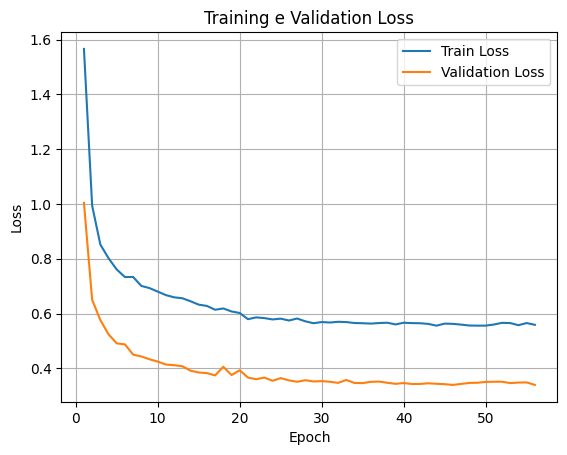

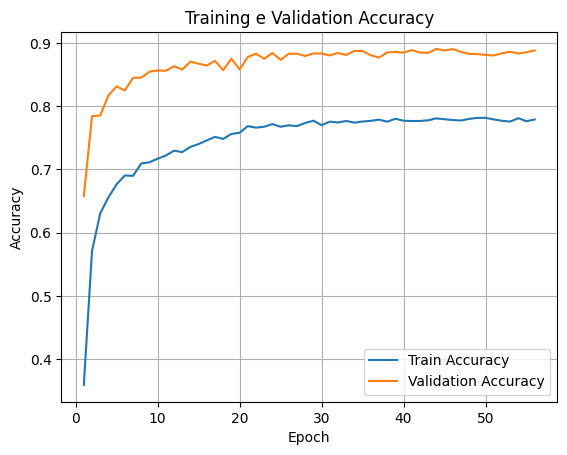

In [24]:
epochs = range(1, len(history["train_loss"]) + 1)

# Loss
plt.figure()
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training e Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Accuracy
plt.figure()
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training e Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### Visualizzazione performance

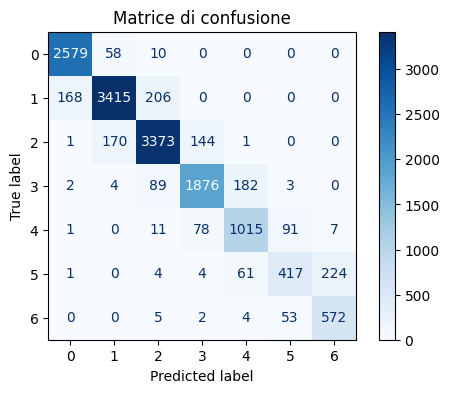

In [25]:
y_test_np = y_test.cpu().numpy()
y_pred_np = y_pred_c.cpu().numpy()

cm = confusion_matrix(y_test_np, y_pred_np)

fig, ax = plt.subplots(figsize=(6, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(7))
disp.plot(cmap='Blues', ax=ax)
plt.title("Matrice di confusione")
plt.show()